# Flu Shot Learning – Exploratory Data Analysis

Ce notebook présente une analyse complète du challenge *Flu Shot Learning*.
L’objectif est de prédire la probabilité qu’un individu reçoive :
- le vaccin contre la grippe saisonnière,
- le vaccin contre la grippe H1N1.

Deux types de modèles sont étudiés :
- Régression Logistique
- Random Forest


## 1. Import des bibliothèques

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

## 2. Chargement et description des données

In [2]:
#chargement des fichiers csv
X = pd.read_csv("/kaggle/input/data-csv/training_set_features.csv")
y = pd.read_csv("/kaggle/input/data-csv/training_set_labels.csv")

#verification que ça marche
X.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb


In [3]:
#la taille et la structure 

print(f"shape of X is {X.shape}")
print(f"shape of y is {y.shape}")

X.info()
print("\n\n")
y.info()

shape of X is (26707, 36)
shape of y is (26707, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  doctor_recc_seasonal         24547 non-null  float64
 12  chronic_med_condition  

## 3. Analyse exploratoire des données (EDA)

### 3.1 Proportion de personnes vaccinées (H1N1 et grippe saisonnière)

In [4]:
y[["h1n1_vaccine", "seasonal_vaccine"]].mean()

h1n1_vaccine        0.212454
seasonal_vaccine    0.465608
dtype: float64

### 3.2 Distribution des personnes vaccinées

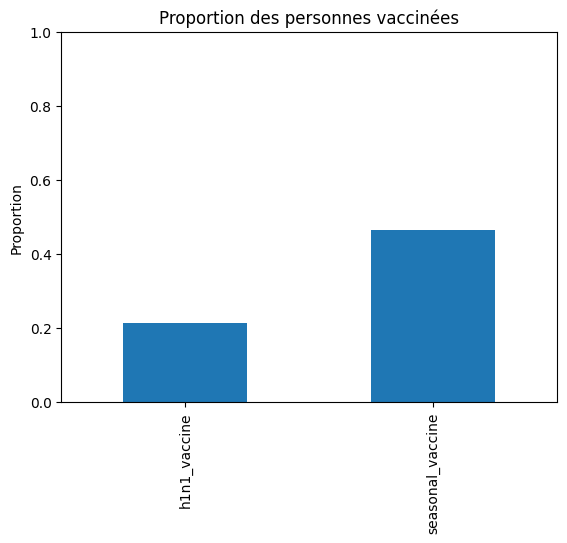

In [5]:
y_labels = y[["h1n1_vaccine", "seasonal_vaccine"]]

y_labels.mean().plot(kind="bar")
plt.title("Proportion des personnes vaccinées")
plt.ylabel("Proportion")
plt.ylim(0, 1)
plt.show()


### 3.3 Analyse des groupes d’âge

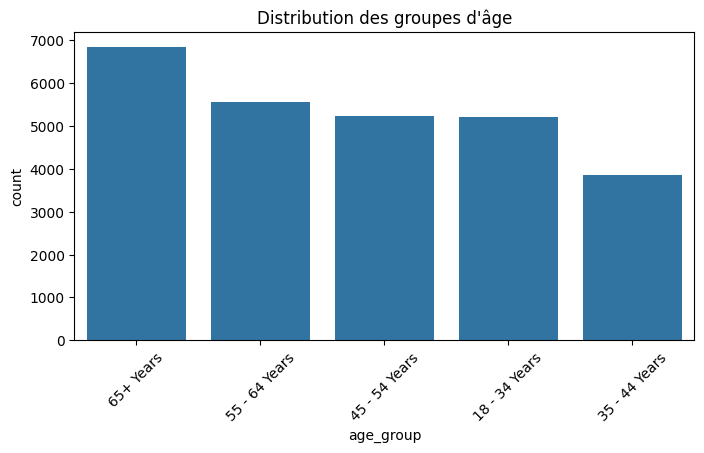

In [6]:
plt.figure(figsize=(8,4))
sns.countplot(data=X, x="age_group", order=X["age_group"].value_counts().index)
plt.title("Distribution des groupes d'âge")
plt.xticks(rotation=45)
plt.show()


### 3.4 Taux de vaccination saisonnière selon l’âge

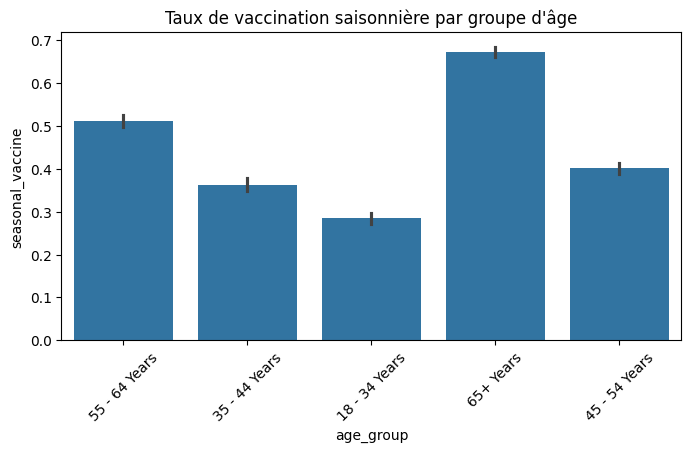

In [7]:
age_vacc = pd.concat([X["age_group"], y["seasonal_vaccine"]], axis=1)

plt.figure(figsize=(8,4))
sns.barplot(data=age_vacc, x="age_group", y="seasonal_vaccine")
plt.title("Taux de vaccination saisonnière par groupe d'âge")
plt.xticks(rotation=45)
plt.show()


### 3.5 Effet de la recommandation médicale sur la vaccination saisonnière

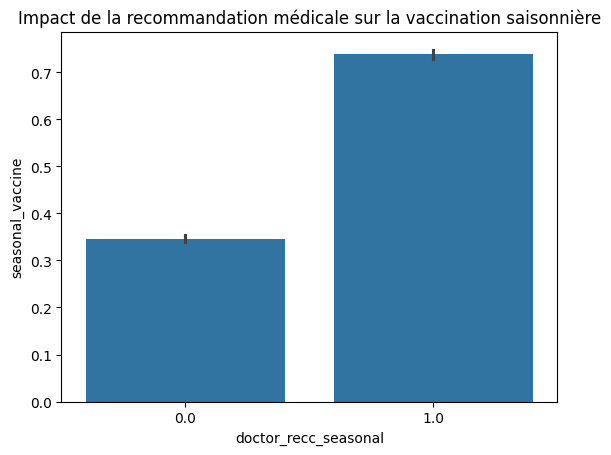

In [8]:
doctor_vacc = pd.concat([X["doctor_recc_seasonal"], y["seasonal_vaccine"]], axis=1)

sns.barplot(data=doctor_vacc, x="doctor_recc_seasonal", y="seasonal_vaccine")
plt.title("Impact de la recommandation médicale sur la vaccination saisonnière")
plt.show()


### 3.6 Influence de l’opinion sur l’efficacité du vaccin

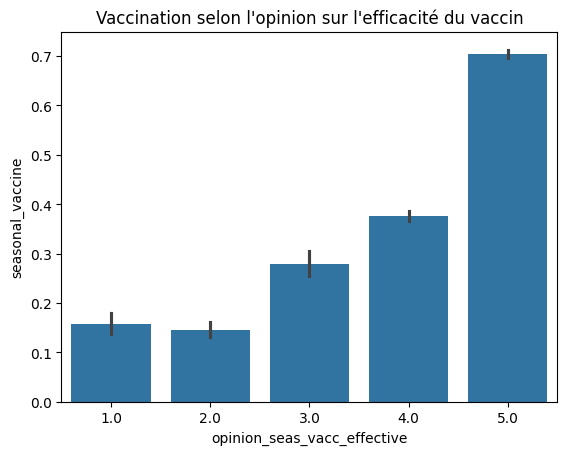

In [9]:
opinion_vacc = pd.concat([X["opinion_seas_vacc_effective"], y["seasonal_vaccine"]], axis=1)

sns.barplot(data=opinion_vacc, x="opinion_seas_vacc_effective", y="seasonal_vaccine")
plt.title("Vaccination selon l'opinion sur l'efficacité du vaccin")
plt.show()


## 4. Prétraitement des données

Avant d’entraîner les modèles, les données doivent être préparées afin d’être exploitables par les algorithmes.  

### 4.1 Séparation des variables explicatives et des variables cibles

Les données fournies contiennent deux variables cibles distinctes :
- `h1n1_vaccine` : indique si un individu a reçu le vaccin H1N1,
- `seasonal_vaccine` : indique si un individu a reçu le vaccin contre la grippe saisonnière.

Ces deux cibles étant différentes, elles sont extraites séparément afin d’entraîner des modèles spécifiques pour chaque prédiction.

In [10]:
y_h1n1 = y["h1n1_vaccine"]
y_seasonal = y["seasonal_vaccine"]

### 4.2 Identification des types de variables

Le jeu de données contient à la fois :
- des variables numériques (par exemple : niveaux de risque, comportements, nombre de personnes dans le foyer),
- des variables catégorielles (par exemple : âge, niveau d’éducation, statut marital, région).

Cette distinction est essentielle car les variables numériques et catégorielles nécessitent des traitements différents lors du prétraitement.

In [11]:
categorical_features = X.select_dtypes(include="object").columns
numerical_features = X.select_dtypes(exclude="object").columns

print("Variables catégorielles :", len(categorical_features))
print("Variables numériques :", len(numerical_features))


Variables catégorielles : 12
Variables numériques : 24


### 4.3 Prétraitement des variables numériques

Les valeurs manquantes des variables numériques sont remplacées par la médiane, afin de limiter l’impact des valeurs extrêmes tout en conservant toutes les observations.

In [12]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

### 4.4 Prétraitement des variables catégorielles

Les variables catégorielles sont traitées en deux étapes :
- les valeurs manquantes sont remplacées par la modalité la plus fréquente,
- les catégories sont transformées en variables binaires à l’aide d’un encodage One-Hot.

L’option `handle_unknown="ignore"` permet d’éviter les erreurs lors de la prédiction sur des données jamais vues.

In [13]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

### 4.5 Construction du pipeline de prétraitement

Le prétraitement des variables numériques et catégorielles est combiné à l’aide d’un `ColumnTransformer`, permettant d’appliquer automatiquement les transformations adaptées à chaque type de variable et d’assurer une intégration reproductible du prétraitement dans le pipeline de machine learning.

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

### 4.6 Séparation des données en ensembles d’entraînement et de test

Afin d’évaluer les performances des modèles, les données sont séparées en :
- un ensemble d’entraînement (80 %),
- un ensemble de test (20 %).

La séparation est réalisée de manière stratifiée afin de conserver la proportion des classes dans chaque ensemble.

In [15]:

X_train, X_test, y_train_seasonal, y_test_seasonal = train_test_split(
    X,
    y_seasonal,
    test_size=0.2,
    random_state=42,
    stratify=y_seasonal
)

### 4.7 Vérification du prétraitement

- Avant l’entraînement des modèles, le bon fonctionnement du pipeline de prétraitement est vérifié en contrôlant la dimension des données après encodage et l’absence de valeurs manquantes.  
- Cette étape garantit que les données sont entièrement numériques et prêtes à être utilisées par les

In [16]:
X_processed = preprocessor.fit_transform(X_train)
X_processed.shape

(21365, 106)

In [19]:
np.isnan(X_processed).sum()

np.int64(0)

## 5. Modélisation et évaluation

Dans cette section, des modèles de classification sont entraînés afin de prédire la probabilité de vaccination.
La régression logistique est utilisée comme modèle de base en raison de sa simplicité et de son interprétabilité.

### 5.1 Régression logistique pour la prédiction du vaccin saisonnier

Ce modèle de classification probabiliste estime la probabilité de vaccination d’un individu à partir de ses caractéristiques socio-démographiques, comportementales et liées à la santé.

#### 5.1.1 Définition du modèle de régression logistique (grippe saisonnière)

In [20]:
log_reg = LogisticRegression(
    max_iter=1000,
    solver="lbfgs"
)

### 5.1.2 Construction du pipeline (prétraitement + modèle)

Le prétraitement et le modèle sont regroupés dans un pipeline unique, assurant l’imputation des valeurs manquantes, l’encodage des variables catégorielles et l’entraînement du modèle sans fuite d’information entre les ensembles d’entraînement et de test.

In [21]:
model_seasonal_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", log_reg)
])

### 5.1.3 Entraînement du modèle

Le modèle est entraîné sur l’ensemble d’entraînement à l’aide du pipeline défini précédemment.

In [22]:
model_seasonal_lr.fit(X_train, y_train_seasonal)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['respondent_id', 'h1n1_concern', 'h1n1_knowledge',
       'behavioral_antiviral_meds', 'behavioral_avoidance',
       'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavi...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region',
       'census_msa', 'employment_industry', 'employment_occupation'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

### 5.1.4 Prédiction des probabilités sur le jeu de test

Le modèle prédit la probabilité qu’un individu ait reçu le vaccin saisonnier.
Ces probabilités sont utilisées pour l’évaluation à l’aide de métriques adaptées.

In [23]:
y_test_proba = model_seasonal_lr.predict_proba(X_test)[:, 1]

### 5.1.5 Évaluation des performances

Les performances du modèle sont évaluées à l’aide de plusieurs métriques :
- le score ROC-AUC (métrique principale),
- l’accuracy,
- la matrice de confusion.

#### ROC-AUC

Le score ROC-AUC mesure la capacité du modèle à discriminer les individus vaccinés des non-vaccinés, indépendamment du seuil de décision.

In [24]:
roc_auc = roc_auc_score(y_test_seasonal, y_test_proba)
roc_auc

np.float64(0.8555182571085934)

#### Accuracy

L’accuracy correspond à la proportion de prédictions correctement classées.

In [25]:
y_test_pred = model_seasonal_lr.predict(X_test)
accuracy = accuracy_score(y_test_seasonal, y_test_pred)
accuracy

0.7839760389367278

#### Matrice de confusion

La matrice de confusion permet d’analyser plus finement les erreurs du modèle en distinguant les faux positifs et les faux négatifs.

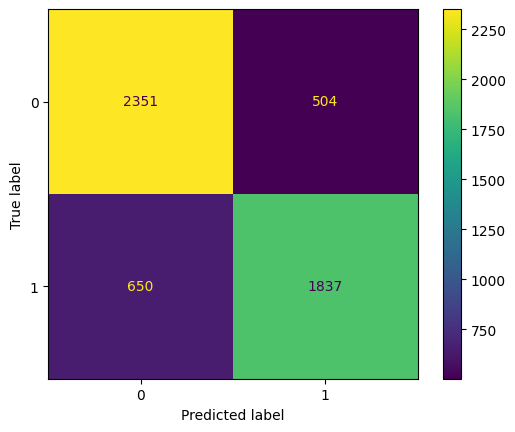

In [26]:
cm = confusion_matrix(y_test_seasonal, y_test_pred)

ConfusionMatrixDisplay(cm).plot()

### 5.2 Régression logistique pour la prédiction du vaccin H1N1

La méthodologie est identique à celle utilisée pour le vaccin saisonnier, seule la variable cible change.

#### 5.2.1 Création des labels H1N1 (train / test)

Afin de garantir une séparation cohérente entre les ensembles d’entraînement et de test, les labels H1N1 sont reconstruits à partir des indices correspondants.

In [27]:
y_train_h1n1 = y_h1n1.loc[X_train.index]
y_test_h1n1 = y_h1n1.loc[X_test.index]

#### 5.2.2 Définition du modèle de régression logistique (H1N1)

In [28]:
log_reg_h1n1 = LogisticRegression(
    max_iter=1000,
    solver="lbfgs"
)

#### 5.2.3 Construction du pipeline complet

In [29]:
model_h1n1_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", log_reg_h1n1)
])

#### 5.2.4 Entraînement du modèle

In [30]:
model_h1n1_lr.fit(X_train, y_train_h1n1)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['respondent_id', 'h1n1_concern', 'h1n1_knowledge',
       'behavioral_antiviral_meds', 'behavioral_avoidance',
       'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavi...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region',
       'census_msa', 'employment_industry', 'employment_occupation'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

#### 5.2.5 Prédiction des probabilités sur le jeu de test

In [31]:
y_test_proba_h1n1 = model_h1n1_lr.predict_proba(X_test)[:, 1]

#### 5.2.6 Évaluation des performances

##### ROC-AUC

In [32]:
roc_auc_h1n1 = roc_auc_score(y_test_h1n1, y_test_proba_h1n1)
roc_auc_h1n1

np.float64(0.8352452515044945)

##### Accuracy

In [33]:
y_test_pred_h1n1 = model_h1n1_lr.predict(X_test)
accuracy_h1n1 = accuracy_score(y_test_h1n1, y_test_pred_h1n1)
accuracy_h1n1

0.8343317109696743

##### Matrice de confusion

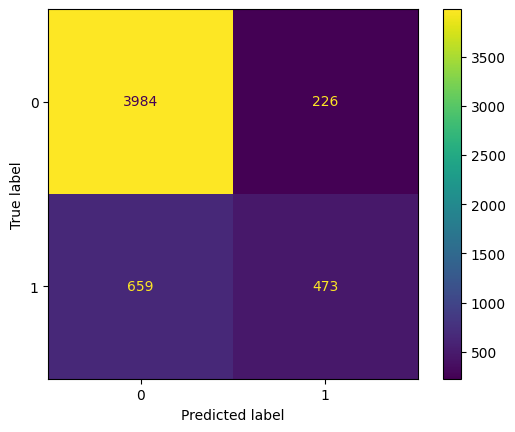

In [34]:
cm_h1n1 = confusion_matrix(y_test_h1n1, y_test_pred_h1n1)
ConfusionMatrixDisplay(cm_h1n1).plot()

### 5.3 Random Forest pour la prédiction du vaccin saisonnier

Afin d’évaluer l’apport d’un modèle plus complexe, une forêt aléatoire est entraînée pour prédire la vaccination saisonnière.

#### 5.3.1 Définition du modèle Random Forest (grippe saisonnière)

In [35]:
rf_seasonal = RandomForestClassifier(
    n_estimators=200, 
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

#### 5.3.2 Construction du pipeline complet

In [36]:
model_seasonal_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", rf_seasonal)
])


#### 5.3.3 Entraînement du modèle

In [37]:
model_seasonal_rf.fit(X_train, y_train_seasonal)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['respondent_id', 'h1n1_concern', 'h1n1_knowledge',
       'behavioral_antiviral_meds', 'behavioral_avoidance',
       'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavi...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region',
       'census_msa', 'employment_industry', 'employment_occupation'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

#### 5.3.4 Prédiction des probabilités sur le jeu de test

In [38]:
y_test_proba_rf = model_seasonal_rf.predict_proba(X_test)[:, 1]

#### 5.3.5 Évaluation des performances

##### ROC-AUC

In [39]:
roc_auc_rf = roc_auc_score(y_test_seasonal, y_test_proba_rf)
roc_auc_rf

np.float64(0.8533052785165876)

##### Accuracy

In [40]:
y_test_pred_rf = model_seasonal_rf.predict(X_test)
accuracy_rf = accuracy_score(y_test_seasonal, y_test_pred_rf)
accuracy_rf

0.7815424934481467

##### Matrice de confusion

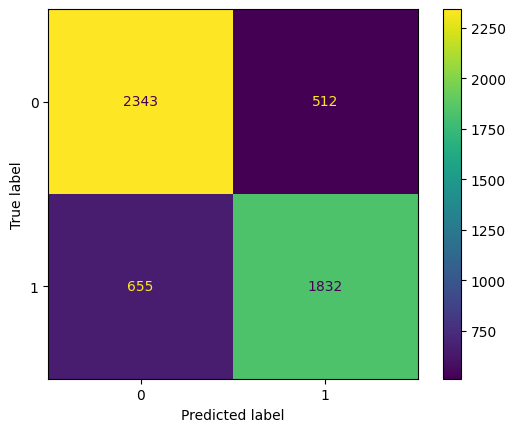

In [41]:
cm_rf = confusion_matrix(y_test_seasonal, y_test_pred_rf)
ConfusionMatrixDisplay(cm_rf).plot()

### 5.4 Random Forest pour la prédiction du vaccin H1N1

Afin de compléter la comparaison des modèles, une forêt aléatoire est entraînée pour prédire la probabilité de vaccination contre le virus H1N1.

#### 5.4.1 Définition du modèle Random Forest (H1N1)

In [42]:
rf_h1n1 = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

#### 5.4.2 Construction du pipeline complet

In [43]:
model_h1n1_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", rf_h1n1)
])

#### 5.4.3 Entraînement du modèle

In [44]:
model_h1n1_rf.fit(X_train, y_train_h1n1)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['respondent_id', 'h1n1_concern', 'h1n1_knowledge',
       'behavioral_antiviral_meds', 'behavioral_avoidance',
       'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavi...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region',
       'census_msa', 'employment_industry', 'employment_occupation'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

#### 5.4.4 Prédiction des probabilités sur le jeu de test

In [45]:
y_test_proba_h1n1_rf = model_h1n1_rf.predict_proba(X_test)[:, 1]

#### 5.4.5 Évaluation des performances


##### ROC-AUC

In [46]:
roc_auc_h1n1_rf = roc_auc_score(y_test_h1n1, y_test_proba_h1n1_rf)
roc_auc_h1n1_rf

np.float64(0.833316267006874)

##### Accuracy

In [47]:
y_test_pred_h1n1_rf = model_h1n1_rf.predict(X_test)
accuracy_h1n1_rf = accuracy_score(y_test_h1n1, y_test_pred_h1n1_rf)
accuracy_h1n1_rf

0.8313365780606514

##### Matrice de confusion

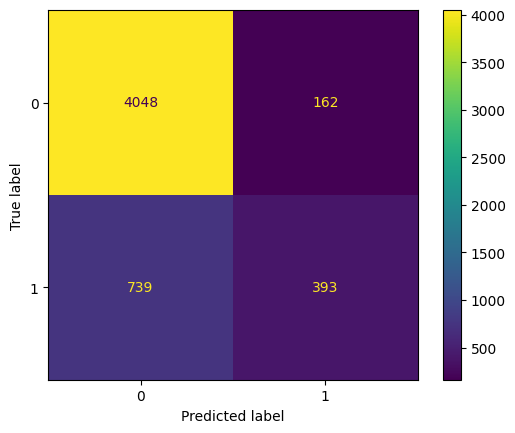

In [48]:
cm_h1n1_rf = confusion_matrix(y_test_h1n1, y_test_pred_h1n1_rf)
ConfusionMatrixDisplay(cm_h1n1_rf).plot()

### 5.5 Comparaison des performances des modèles

Afin de comparer les différentes approches étudiées, les scores ROC-AUC obtenus pour chaque modèle et chaque cible sont rassemblés dans un tableau récapitulatif.

Cette comparaison permet d’évaluer :
- l’impact du choix du modèle (régression logistique vs Random Forest),
- les différences de performance entre la prédiction du vaccin saisonnier et celle du vaccin H1N1.

In [49]:
results = pd.DataFrame({
    "Modèle": [
        "Régression Logistique – Seasonal",
        "Random Forest – Seasonal",
        "Régression Logistique – H1N1",
        "Random Forest – H1N1"
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_rf,
        roc_auc_h1n1,
        roc_auc_h1n1_rf
    ]
})

results

,Modèle,ROC-AUC
0,Régression Logistique – Seasonal,0.855518
1,Random Forest – Seasonal,0.853305
2,Régression Logistique – H1N1,0.835245
3,Random Forest – H1N1,0.833316


## 6. Entraînement final et prédictions sur les données du challenge

Dans cette partie finale, nous entraînons les modèles sélectionnés sur l’ensemble des données disponibles,
puis nous générons les prédictions demandées par le challenge DrivenData.
Les données de test du challenge ne contiennent pas les labels.

### 6.1 Sélection du modèle et préparation des données complètes

Les modèles finaux sont entraînés sur toutes les observations disponibles.
La colonne `respondent_id` est supprimée car elle ne doit pas être utilisée comme variable explicative.

In [50]:
X_no_id = X.drop(columns=["respondent_id"])
num_features = X_no_id.select_dtypes(include=["int64", "float64"]).columns
cat_features = X_no_id.select_dtypes(include=["object"]).columns
preprocessor_final = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ]
)

In [51]:
X_full = X_no_id.copy()

y_full_seasonal = y_seasonal
y_full_h1n1 = y_h1n1

### 6.2 Entraînement du modèle final – Vaccin saisonnier

Le modèle final de régression logistique pour la vaccination saisonnière est entraîné
sur l’ensemble des données disponibles.

In [52]:
final_model_seasonal = Pipeline(steps=[
    ("preprocessor", preprocessor_final),
    ("classifier", LogisticRegression(max_iter=1000, solver="lbfgs"))
])

final_model_seasonal.fit(X_full, y_full_seasonal)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds',
       'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face'...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region',
       'census_msa', 'employment_industry', 'employment_occupation'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

### 6.3 Entraînement du modèle final – Vaccin H1N1

Un second modèle de régression logistique est entraîné pour prédire la vaccination H1N1,
en utilisant le même prétraitement.

In [53]:
final_model_h1n1 = Pipeline(steps=[
    ("preprocessor", preprocessor_final),
    ("classifier", LogisticRegression(max_iter=1000, solver="lbfgs"))
])

final_model_h1n1.fit(X_full, y_full_h1n1)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds',
       'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face'...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region',
       'census_msa', 'employment_industry', 'employment_occupation'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

### 6.4 Chargement des données de test du challenge

Les données de test fournies par le challenge sont chargées.
La colonne `respondent_id` est conservée séparément pour la création du fichier de soumission.

In [54]:
X_challenge_test = pd.read_csv("/kaggle/input/data-csv/test_set_features.csv")

# Suppression de l'identifiant
respondent_ids = X_challenge_test["respondent_id"]
X_challenge_test = X_challenge_test.drop(columns=["respondent_id"])
X_challenge_test.shape

(26708, 35)

### 6.5 Alignement des colonnes 

Les colonnes du jeu de test sont alignées avec celles utilisées lors de l’entraînement
afin d’éviter toute incohérence lors de la prédiction.

In [55]:
X_challenge_test = X_challenge_test.reindex(columns=X_full.columns)

### 6.6 Prédiction des probabilités

Les modèles finaux sont utilisés pour prédire les probabilités de vaccination
contre la grippe saisonnière et le virus H1N1.

In [56]:
proba_seasonal = final_model_seasonal.predict_proba(X_challenge_test)[:, 1]
proba_h1n1 = final_model_h1n1.predict_proba(X_challenge_test)[:, 1]

### 6.7 Création du fichier de soumission

Les probabilités prédites sont intégrées dans le format de soumission officiel.
Le fichier final est exporté au format CSV et prêt à être soumis sur la plateforme DrivenData.

In [57]:
submission = pd.read_csv("/kaggle/input/data-csv/submission_format.csv")

submission["respondent_id"] = respondent_ids
submission["h1n1_vaccine"] = proba_h1n1
submission["seasonal_vaccine"] = proba_seasonal

submission.to_csv("submission_finale.csv", index=False)
submission.head()

,respondent_id,h1n1_vaccine,seasonal_vaccine
0,26707,0.055771,0.292964
1,26708,0.047970,0.044805
2,26709,0.436125,0.585665
3,26710,0.498385,0.880880
4,26711,0.160937,0.469905


## Conclusion

Ce notebook a permis de construire et d’évaluer des modèles de prédiction de la vaccination contre la grippe saisonnière et le H1N1, en respectant les objectifs du challenge DrivenData.  
Les résultats montrent que la régression logistique offre des performances solides en termes de ROC-AUC, comparables voire supérieures à la Random Forest, avec une complexité moindre.  
Les modèles finaux ont été entraînés sur l’ensemble des données et utilisés pour générer les probabilités demandées sur le jeu de test du challenge.